# Business Understanding

## Project Domain

Domain proyek ini adalah sistem tenaga listrik dan pemeliharaan prediktif, yang berfokus pada pendeteksian dan klasifikasi kegagalan/gangguan listrik. Proyek ini melibatkan bidang teknik elektro, kecerdasan buatan, dan pemrosesan sinyal untuk mengidentifikasi dan mengklasifikasikan berbagai jenis gangguan pada sistem listrik.

## Problem Statements

1. Gangguan listrik yang tidak terdeteksi dengan cepat dapat menyebabkan kerusakan peralatan yang serius, gangguan layanan, dan bahaya keselamatan.
2. Metode konvensional untuk deteksi gangguan sering memerlukan intervensi manual dan tidak dapat memberikan identifikasi gangguan secara real-time.
3. Sulit untuk membedakan antara berbagai jenis gangguan listrik (fase tunggal ke tanah, fase ke fase, tiga fase) secara akurat dan cepat.
4. Data gangguan listrik sering kompleks dan memerlukan teknik analisis khusus untuk interpretasi yang tepat.
5. Sistem distribusi listrik modern membutuhkan pendekatan yang lebih pintar dan otomatis untuk deteksi dan klasifikasi gangguan.

## Goals

1. Mengembangkan sistem otomatis yang dapat mendeteksi gangguan listrik secara real-time dengan tingkat akurasi tinggi.
2. Mengklasifikasikan gangguan listrik ke dalam kategori yang tepat (misalnya gangguan fase tunggal ke tanah, fase ke fase, tiga fase).
3. Mengurangi waktu identifikasi gangguan untuk meminimalkan dampak gangguan pada sistem.
4. Meningkatkan keandalan sistem distribusi listrik melalui deteksi gangguan yang lebih cepat dan akurat.
5. Menyediakan sistem peringatan dini untuk mencegah kerusakan peralatan yang lebih luas.

## Solution Statements

1. Mengembangkan sistem berbasis kecerdasan buatan (AI) untuk deteksi dan klasifikasi gangguan listrik menggunakan algoritma pembelajaran mesin/deep learning.
2. Mengimplementasikan pemrosesan sinyal digital untuk mengekstraksi fitur-fitur penting dari data arus dan tegangan.
3. Merancang dan melatih model klasifikasi gangguan menggunakan data historis gangguan listrik untuk mengidentifikasi pola gangguan yang berbeda.
4. Mengintegrasikan sistem dengan infrastruktur pemantauan yang ada untuk memberikan deteksi gangguan secara real-time.
5. Mengembangkan antarmuka pengguna yang memungkinkan operator mengamati dan menindaklanjuti peringatan gangguan listrik dengan cepat.
6. Menerapkan sistem validasi untuk memverifikasi akurasi deteksi dan klasifikasi gangguan, serta meminimalisir peringatan palsu.

# Data Understanding

## Import data dari kaggle

In [1]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sarifudin2106","key":"f9369812466b6068f08869de4bc4ae8a"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!ls ~/.kaggle

kaggle.json


In [3]:
!kaggle datasets download -d esathyaprakash/electrical-fault-detection-and-classification

Dataset URL: https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification
License(s): CC0-1.0


In [4]:
!mkdir electrical-fault-detection-and-classification
!unzip electrical-fault-detection-and-classification.zip -d detecting-electrical-faults
!ls detecting-electrical-faults

Archive:  electrical-fault-detection-and-classification.zip
  inflating: detecting-electrical-faults/classData.csv  
  inflating: detecting-electrical-faults/detect_dataset.csv  
classData.csv  detect_dataset.csv


## Import Library yang dibutuhkan

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import scipy.stats as stats
from tensorflow import keras
from keras.models import Sequential
from tensorflow import keras
from keras.layers import Dense
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,BaggingClassifier,AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

## Exploratory Data Analysis

In [6]:
df = pd.read_csv('detecting-electrical-faults/detect_dataset.csv')

In [7]:
df.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc,Unnamed: 7,Unnamed: 8
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431,NaN,NaN
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202,NaN,NaN
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251,NaN,NaN
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963,NaN,NaN
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050,NaN,NaN


In [8]:
df.shape

(12001, 9)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12001 entries, 0 to 12000
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Output (S)  12001 non-null  int64  
 1   Ia          12001 non-null  float64
 2   Ib          12001 non-null  float64
 3   Ic          12001 non-null  float64
 4   Va          12001 non-null  float64
 5   Vb          12001 non-null  float64
 6   Vc          12001 non-null  float64
 7   Unnamed: 7  0 non-null      float64
 8   Unnamed: 8  0 non-null      float64
dtypes: float64(8), int64(1)
memory usage: 843.9 KB


In [10]:
df.describe()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc,Unnamed: 7,Unnamed: 8
count,12001.000000,12001.000000,12001.000000,12001.000000,12001.000000,12001.000000,12001.000000,0.0,0.0
mean,0.457962,6.709369,-26.557793,22.353043,0.010517,-0.015498,0.004980,NaN,NaN
std,0.498250,377.158470,357.458613,302.052809,0.346221,0.357644,0.349272,NaN,NaN
min,0.000000,-883.542316,-900.526951,-883.357762,-0.620748,-0.659921,-0.612709,NaN,NaN
25%,0.000000,-64.348986,-51.421937,-54.562257,-0.237610,-0.313721,-0.278951,NaN,NaN
50%,0.000000,-3.239788,4.711283,-0.399419,0.002465,-0.007192,0.008381,NaN,NaN
75%,1.000000,53.823453,69.637787,45.274542,0.285078,0.248681,0.289681,NaN,NaN
max,1.000000,885.738571,889.868884,901.274261,0.609864,0.627875,0.608243,NaN,NaN


In [11]:
df.isnull().sum()

,0
Output (S),0
Ia,0
Ib,0
Ic,0
Va,0
Vb,0
Vc,0
Unnamed: 7,12001
Unnamed: 8,12001


In [12]:
df.drop(['Unnamed: 7','Unnamed: 8'],axis=1,inplace = True)

In [13]:
df.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df['Output (S)'].unique()

array([0, 1])

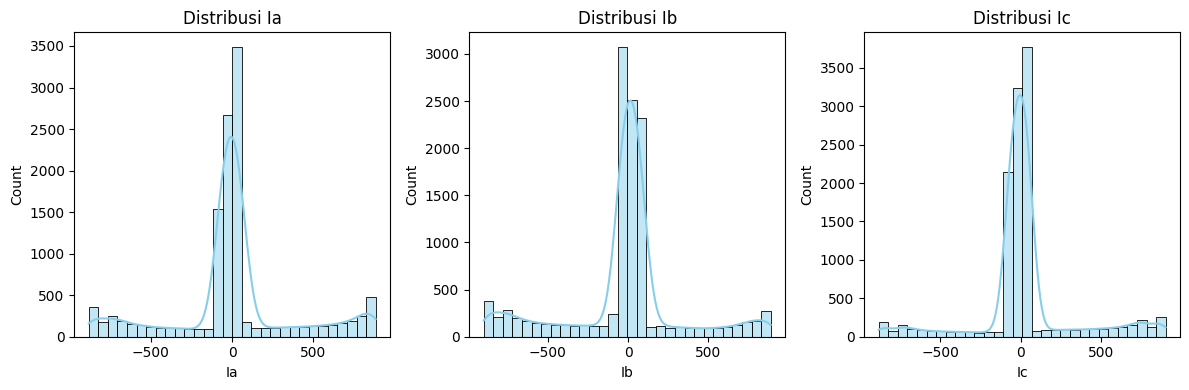

In [16]:
# 1. Histogram Arus (Ia, Ib, Ic)
plt.figure(figsize=(12, 4))
for i, col in enumerate(['Ia', 'Ib', 'Ic']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

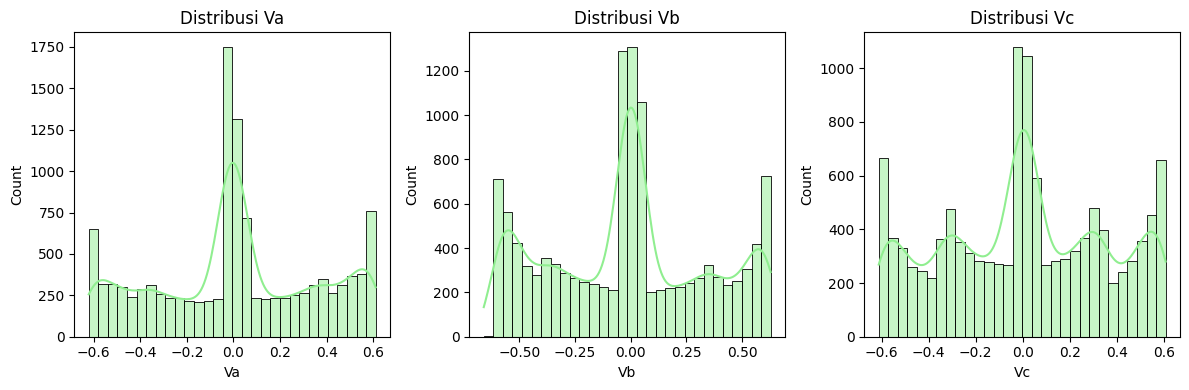

In [17]:
# 2. Histogram Tegangan (Va, Vb, Vc)
plt.figure(figsize=(12, 4))
for i, col in enumerate(['Va', 'Vb', 'Vc']):
    plt.subplot(1, 3, i+1)
    sns.histplot(df[col], kde=True, bins=30, color='lightgreen')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

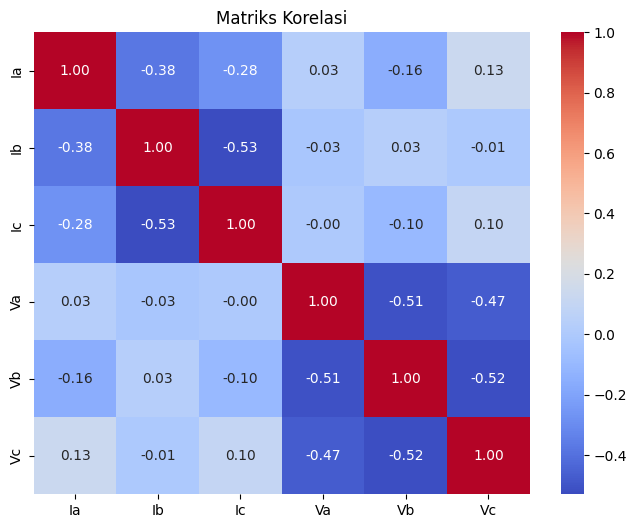

In [18]:
# 3. Heatmap Korelasi
plt.figure(figsize=(8, 6))
correlation = df[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriks Korelasi")
plt.show()

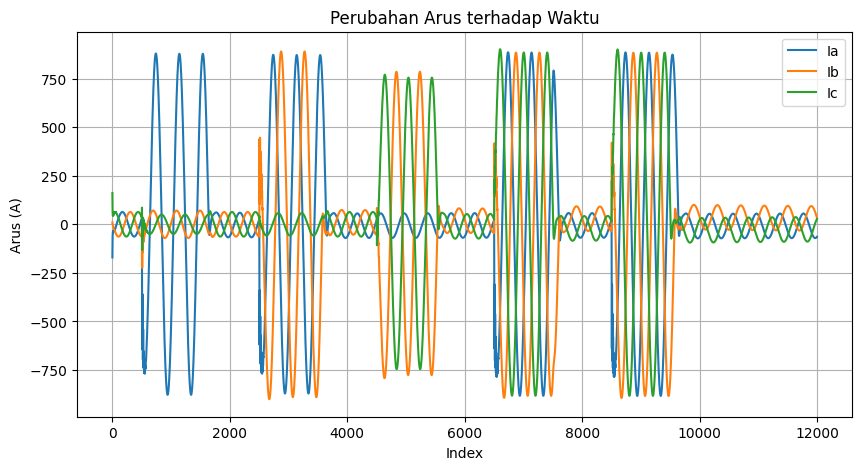

In [19]:
# 4. Line Plot Arus
plt.figure(figsize=(10, 5))
for col in ['Ia', 'Ib', 'Ic']:
    plt.plot(df[col], label=col)
plt.title("Perubahan Arus terhadap Waktu")
plt.xlabel("Index")
plt.ylabel("Arus (A)")
plt.legend()
plt.grid(True)
plt.show()

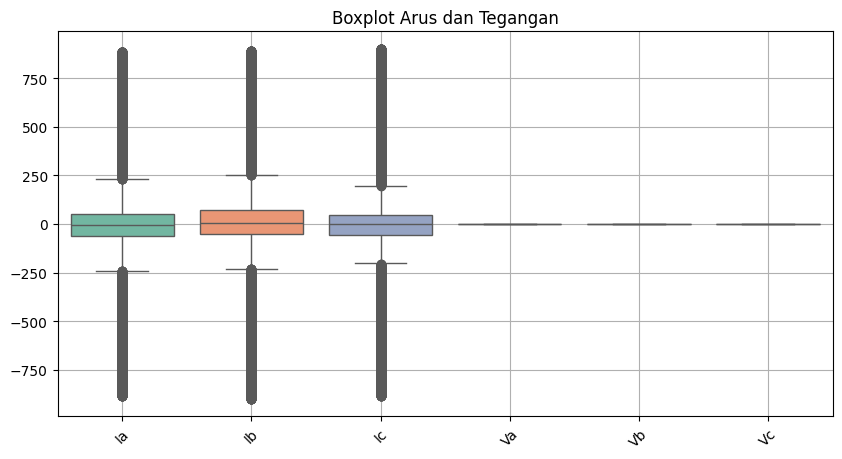

In [20]:
# 5. Boxplot Arus dan Tegangan
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']], palette='Set2')
plt.title("Boxplot Arus dan Tegangan")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

# Data Preparation

In [21]:
df.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12001 entries, 0 to 12000
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Output (S)  12001 non-null  int64  
 1   Ia          12001 non-null  float64
 2   Ib          12001 non-null  float64
 3   Ic          12001 non-null  float64
 4   Va          12001 non-null  float64
 5   Vb          12001 non-null  float64
 6   Vc          12001 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 656.4 KB


In [23]:
print(df.columns)

Index(['Output (S)', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc'], dtype='object')


In [24]:
x_train,x_test,y_train,y_test = train_test_split(df.drop('Output (S)',axis=1),df['Output (S)'],random_state=42,test_size=0.2)

In [25]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Modeling

In [26]:
model = Sequential()
model.add(Dense(256, activation='relu', input_shape = (x_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [27]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,057 (176.00 KB)

 Trainable params: 45,057 (176.00 KB)

 Non-trainable params: 0 (0.00 B)

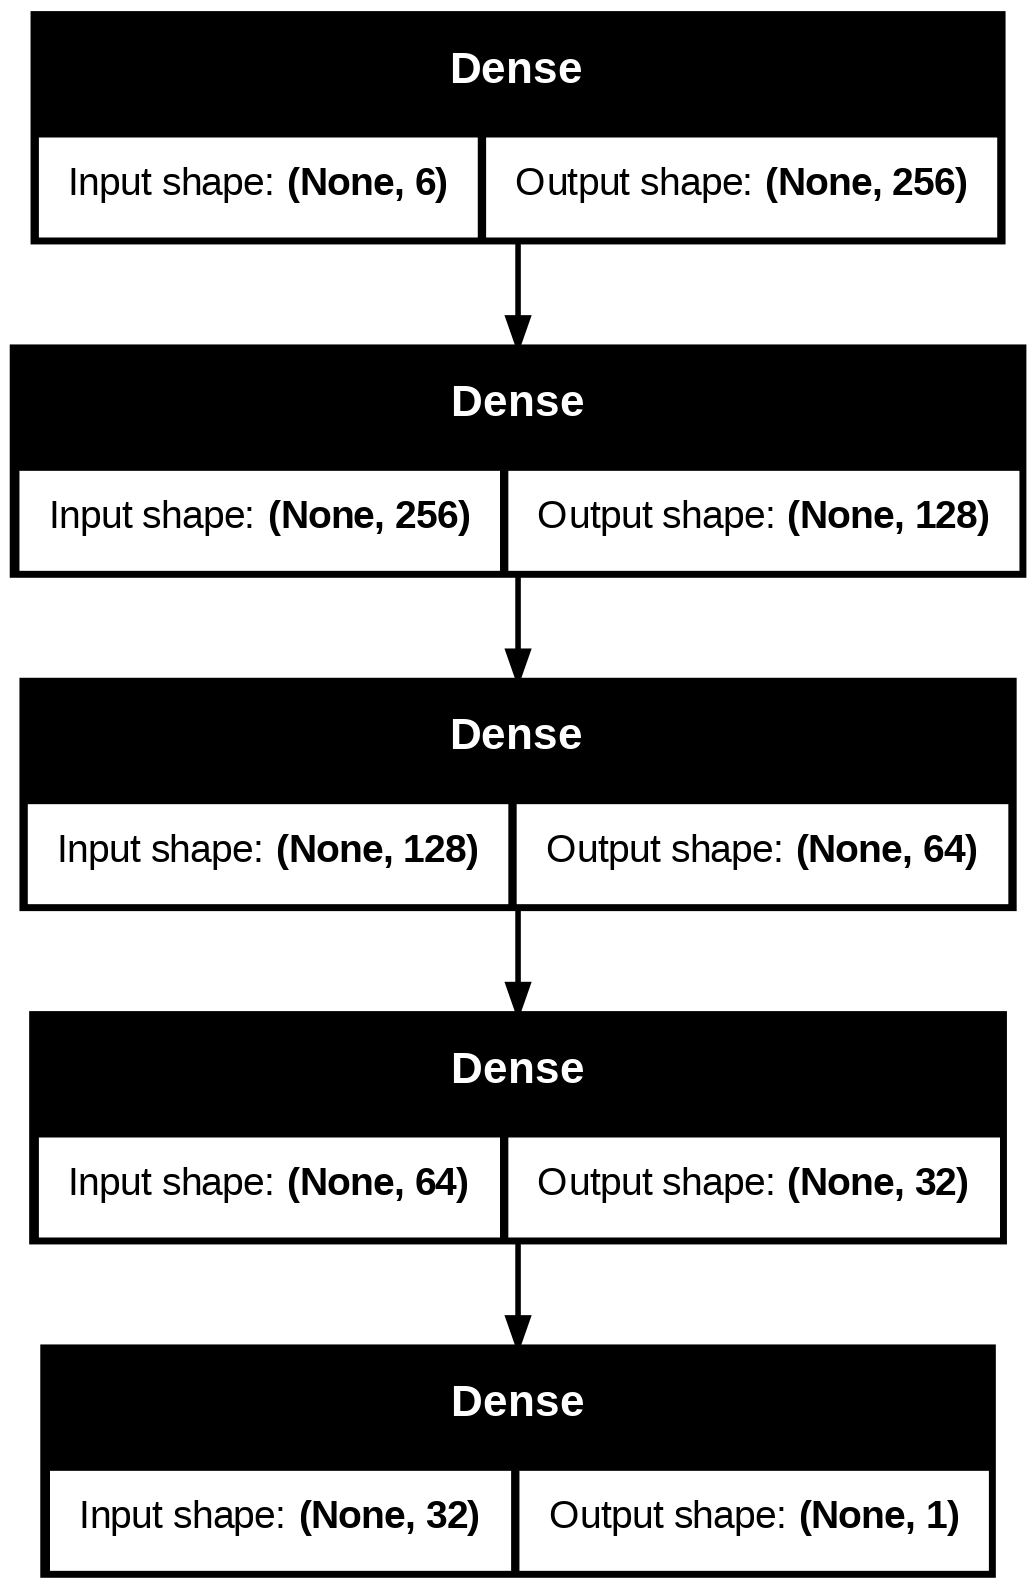

In [29]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True)

In [30]:
history = model.fit(x_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_data=(x_test, y_test))

Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9613 - loss: 0.1459 - val_accuracy: 0.9879 - val_loss: 0.0457
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9876 - loss: 0.0436 - val_accuracy: 0.9938 - val_loss: 0.0228
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9900 - loss: 0.0292 - val_accuracy: 0.9929 - val_loss: 0.0179
Epoch 4/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9911 - loss: 0.0269 - val_accuracy: 0.9929 - val_loss: 0.0256
Epoch 5/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9931 - loss: 0.0210 - val_accuracy: 0.9933 - val_loss: 0.0225
Epoch 6/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9936 - loss: 0.0199 - val_accuracy: 0.9946 - val_loss: 0.0156
Epoch 7/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9920 - loss: 0.0207 - val_accuracy: 0.9917 - val_loss: 0.0170
Epoch 8/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9937 - loss: 0.0177 - val_accuracy: 0.

# Evaluation

In [31]:
# Evaluate the model
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Loss: 0.0089
Test Accuracy: 99.50%


In [32]:
# Make predictions
y_pred = model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype(int)

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [33]:
# Print classification report
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1306
           1       0.99      1.00      0.99      1095

    accuracy                           1.00      2401
   macro avg       0.99      1.00      0.99      2401
weighted avg       1.00      1.00      1.00      2401



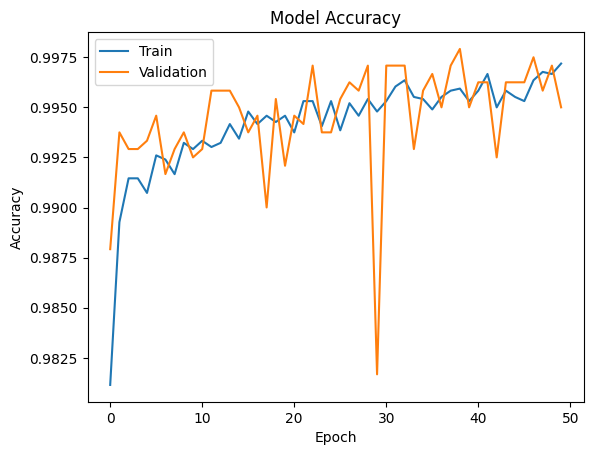

In [34]:
# Plot training history (optional)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

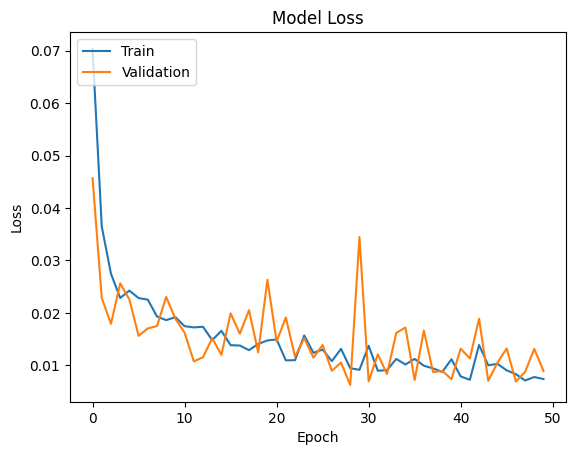

In [35]:
# Plot training history (optional)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


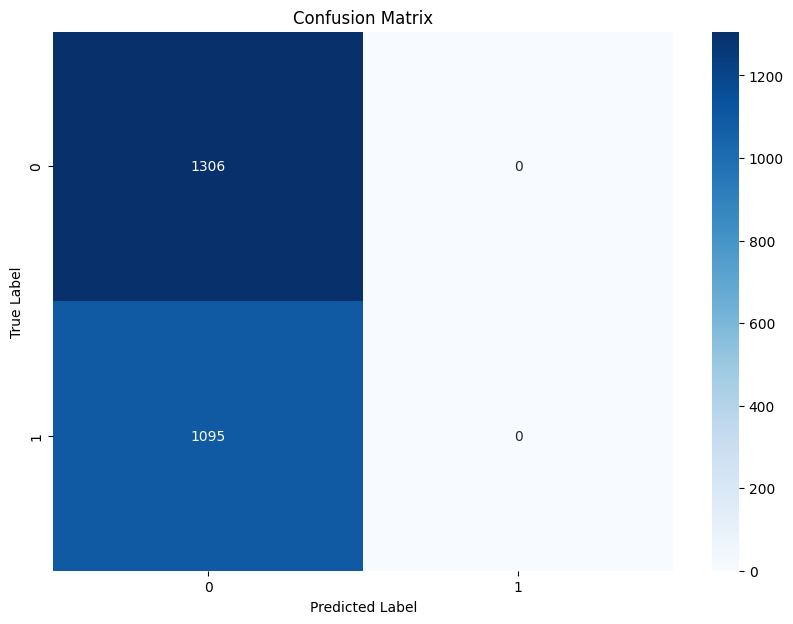

Classification Report:
              precision    recall  f1-score   support

           0       0.54      1.00      0.70      1306
           1       0.00      0.00      0.00      1095

    accuracy                           0.54      2401
   macro avg       0.27      0.50      0.35      2401
weighted avg       0.30      0.54      0.38      2401



In [36]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred_classes))

# Deployment

## Model Simulation

In [37]:
df.head()

,Output (S),Ia,Ib,Ic,Va,Vb,Vc
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050


In [38]:
sample_index = np.random.randint(1, len(df))
sample_data = df.drop('Output (S)', axis=1).iloc[[sample_index]]

In [39]:
sample_data_scaled = sc.transform(sample_data)

In [40]:
prediction = model.predict(sample_data_scaled)
predicted = (prediction > 0.5).astype(int)

print(f"Sample data:\n{sample_data}")
print(f"\nPredicted: {predicted[0][0]}")
print(f"Actual : {df['Output (S)'].iloc[sample_index]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Sample data:
              Ia          Ib         Ic        Va        Vb        Vc
7562  483.476378 -500.396023  19.058338  0.031281 -0.508204  0.476923

Predicted: 1
Actual : 1


## Save Model

In [41]:
# Konversi model ke TFLite
import tensorflow as tf # Import TensorFlow before using it
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Simpan model
with open('detecting-electrical-faults.tflite', 'wb') as f:
    f.write(tflite_model)

Saved artifact at '/tmp/tmp167pgqf1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140246764031824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249377898128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140246764032208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140246764030672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140246764029328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140246764030288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249378531728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249378522704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249378521360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140249378524816: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [42]:
# Simpan label encoder dan scaler
import joblib
# Since 'le' is not defined, create and fit it to your data if necessary.
# Assuming 'Output (S)' is the target column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le.fit(df['Output (S)'])
joblib.dump(le, 'label_encoder.pkl')
# If 'scaler' refers to the StandardScaler used earlier, change it to 'sc'
joblib.dump(sc, 'scaler.pkl')

['scaler.pkl']